In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('country_vaccinations.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape: (86512, 15)
Columns: ['country', 'iso_code', 'date', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'daily_vaccinations_raw', 'daily_vaccinations', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hundred', 'daily_vaccinations_per_million', 'vaccines', 'source_name', 'source_website']


,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website
0,Afghanistan,AFG,2021-02-22,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
1,Afghanistan,AFG,2021-02-23,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
2,Afghanistan,AFG,2021-02-24,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
3,Afghanistan,AFG,2021-02-25,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
4,Afghanistan,AFG,2021-02-26,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/


In [ ]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())
print("\nTotal Countries:", df['country'].nunique())
print("Date Range:", df['date'].min(), "to", df['date'].max())

Missing Values:
country                                    0
iso_code                                   0
date                                       0
total_vaccinations                     42905
people_vaccinated                      45218
people_fully_vaccinated                47710
daily_vaccinations_raw                 51150
daily_vaccinations                       299
total_vaccinations_per_hundred         42905
people_vaccinated_per_hundred          45218
people_fully_vaccinated_per_hundred    47710
daily_vaccinations_per_million           299
vaccines                                   0
source_name                                0
source_website                             0
dtype: int64

Total Countries: 223
Date Range: 2020-12-02 to 2022-03-29


In [ ]:
# Fill missing values and fix date column
df[['total_vaccinations','people_vaccinated',
    'people_fully_vaccinated','daily_vaccinations']] = \
df[['total_vaccinations','people_vaccinated',
    'people_fully_vaccinated','daily_vaccinations']].fillna(0)

df['date'] = pd.to_datetime(df['date'])
df['month_year'] = df['date'].dt.to_period('M').astype(str)
df['year'] = df['date'].dt.year

print("✅ Data Cleaned!")
print("Shape:", df.shape)

✅ Data Cleaned!
Shape: (86512, 17)


/tmp/ipython-input-427/388370852.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='total_vaccinations', y='country', palette='Blues_d')


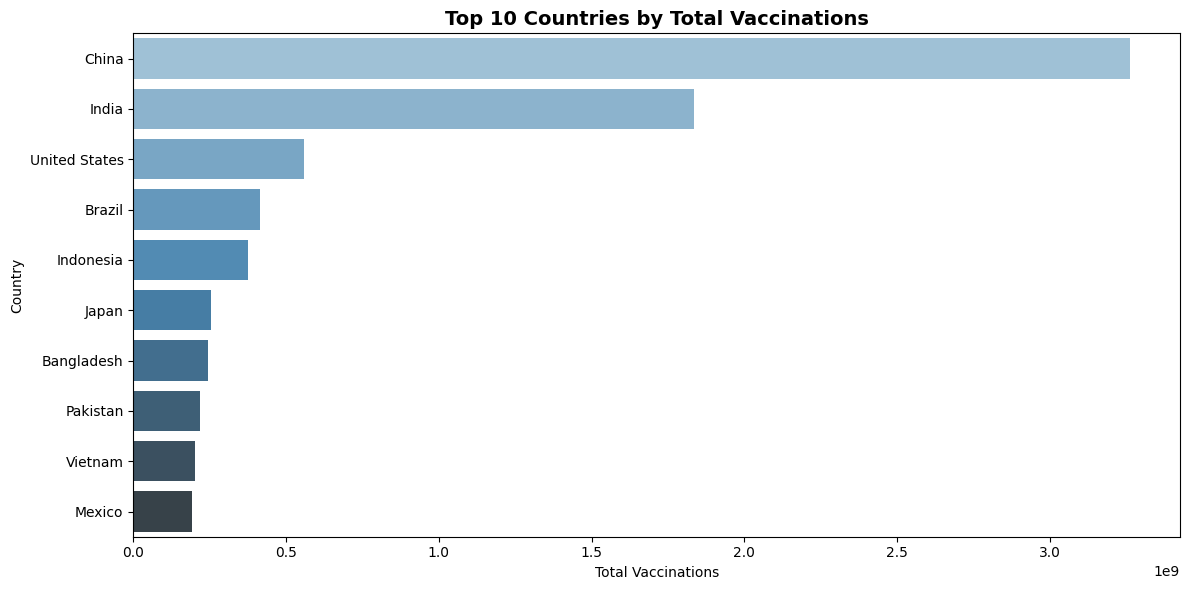

✅ Chart saved!


In [ ]:
# Latest data per country
latest = df.groupby('country').last().reset_index()

# Top 10 by total vaccinations
top10 = latest.nlargest(10, 'total_vaccinations')

plt.figure(figsize=(12, 6))
sns.barplot(data=top10, x='total_vaccinations', y='country', palette='Blues_d')
plt.title('Top 10 Countries by Total Vaccinations', fontsize=14, fontweight='bold')
plt.xlabel('Total Vaccinations')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('top10_vaccinations.png', dpi=150)
plt.show()
print("✅ Chart saved!")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('country_vaccinations.csv')

# Clean data
df[['total_vaccinations','people_vaccinated',
    'people_fully_vaccinated','daily_vaccinations']] = \
df[['total_vaccinations','people_vaccinated',
    'people_fully_vaccinated','daily_vaccinations']].fillna(0)

df['date'] = pd.to_datetime(df['date'])
df['month_year'] = df['date'].dt.to_period('M').astype(str)
df['year'] = df['date'].dt.year

# Latest data per country
latest = df.groupby('country').last().reset_index()

# Global daily trend
global_trend = df.groupby('date')['daily_vaccinations'].sum().reset_index()

print("✅ Data loaded and cleaned!")
print("Shape:", df.shape)
print("Countries:", df['country'].nunique())
print("Date Range:", df['date'].min(), "to", df['date'].max())

✅ Data loaded and cleaned!
Shape: (86512, 17)
Countries: 223
Date Range: 2020-12-02 00:00:00 to 2022-03-29 00:00:00


/tmp/ipython-input-427/2680856185.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vaccine_counts, x='country_count',


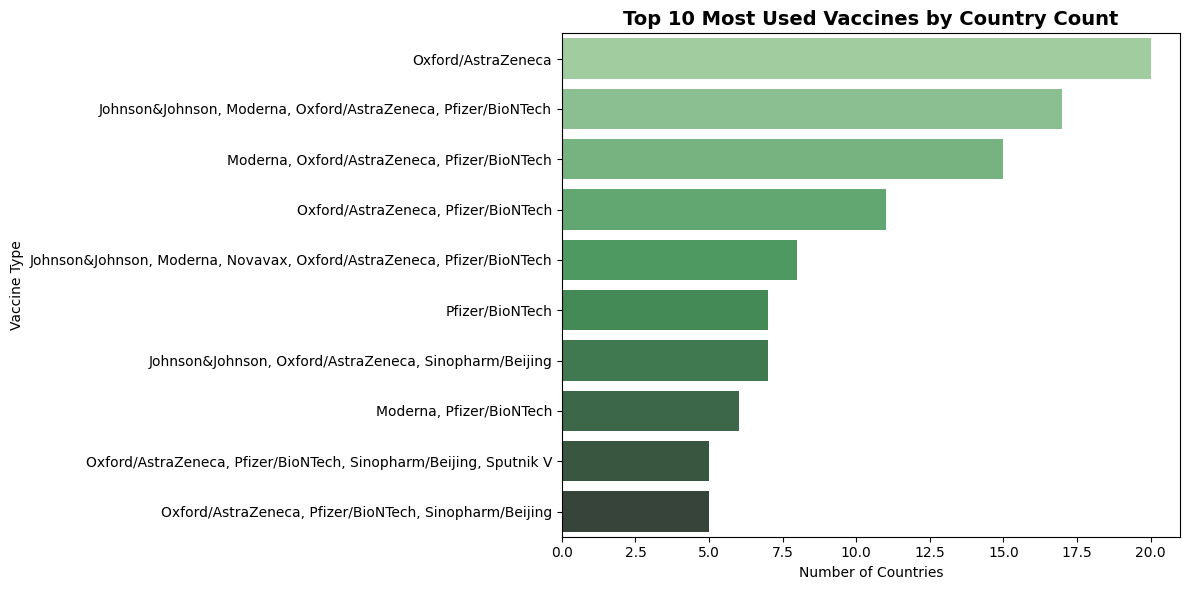

✅ Chart saved!


In [ ]:
vaccine_counts = df.groupby('vaccines')['country'].nunique().reset_index()
vaccine_counts.columns = ['vaccines', 'country_count']
vaccine_counts = vaccine_counts.sort_values(
    'country_count', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=vaccine_counts, x='country_count',
            y='vaccines', palette='Greens_d')
plt.title('Top 10 Most Used Vaccines by Country Count',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Countries')
plt.ylabel('Vaccine Type')
plt.tight_layout()
plt.savefig('vaccine_types.png', dpi=150)
plt.show()
print("✅ Chart saved!")

/tmp/ipython-input-427/2275375836.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_full, x='people_fully_vaccinated',


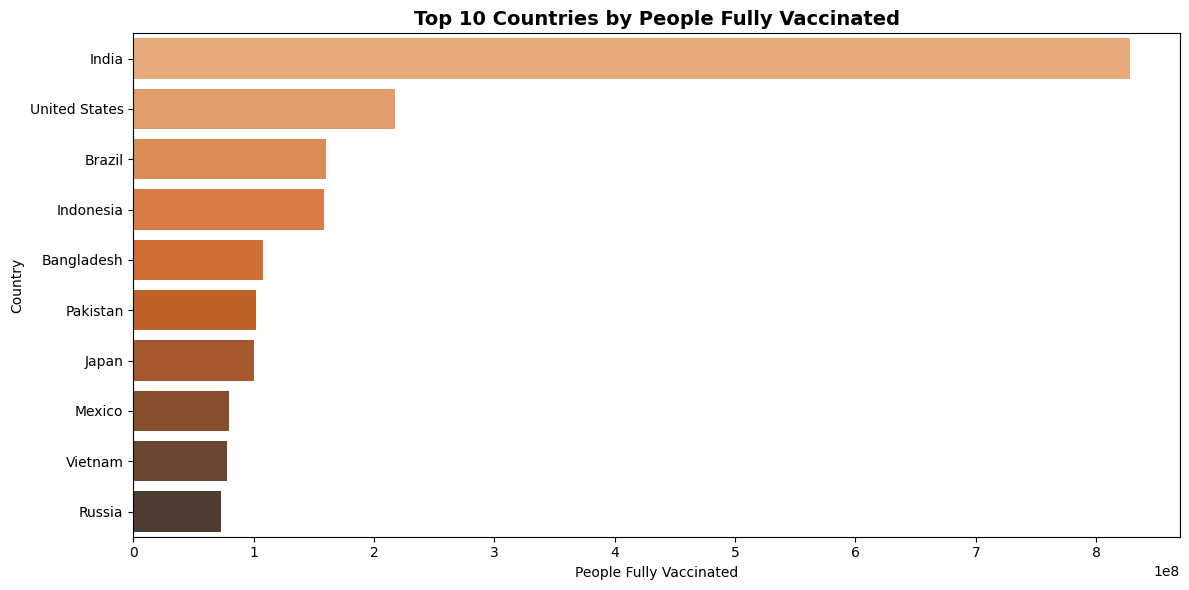

✅ Chart saved!


In [ ]:
top10_full = latest.nlargest(10, 'people_fully_vaccinated')

plt.figure(figsize=(12, 6))
sns.barplot(data=top10_full, x='people_fully_vaccinated',
            y='country', palette='Oranges_d')
plt.title('Top 10 Countries by People Fully Vaccinated',
          fontsize=14, fontweight='bold')
plt.xlabel('People Fully Vaccinated')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('fully_vaccinated.png', dpi=150)
plt.show()
print("✅ Chart saved!")

In [ ]:
df.to_csv('covid_vaccinations_cleaned.csv', index=False)
latest.to_csv('covid_latest_by_country.csv', index=False)

print("✅ All Files Saved:")
print("   - covid_vaccinations_cleaned.csv")
print("   - covid_latest_by_country.csv")
print("   - top10_vaccinations.png")
print("   - global_daily_trend.png")
print("   - vaccine_types.png")
print("   - fully_vaccinated.png")
print("\n✅ Python Analysis Complete!")

✅ All Files Saved:
   - covid_vaccinations_cleaned.csv
   - covid_latest_by_country.csv
   - top10_vaccinations.png
   - global_daily_trend.png
   - vaccine_types.png
   - fully_vaccinated.png

✅ Python Analysis Complete!


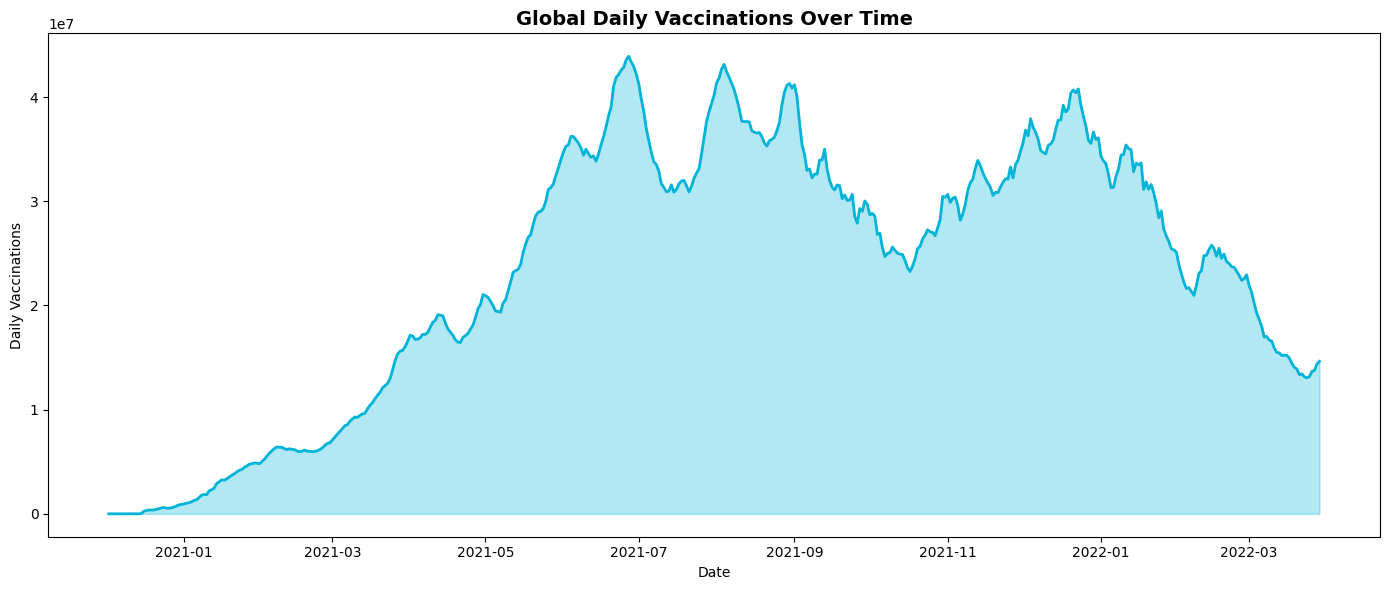

✅ global_daily_trend.png saved!


In [11]:
# Global Daily Trend
global_trend = df.groupby('date')['daily_vaccinations'].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(global_trend['date'], global_trend['daily_vaccinations'],
         color='#00B4D8', linewidth=2)
plt.fill_between(global_trend['date'], global_trend['daily_vaccinations'],
                 alpha=0.3, color='#00B4D8')
plt.title('Global Daily Vaccinations Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Daily Vaccinations')
plt.tight_layout()
plt.savefig('global_daily_trend.png', dpi=150)
plt.show()
print("✅ global_daily_trend.png saved!")